# 2-m air temperature: MOSAiC observations vs. IFS vs. CARRA2

Comparison of 2-m air temperature along the MOSAiC drift from three sources:

| source | file | native sampling |
|---|---|---|
| **MOSAiC obs** (Met City tower) | `data/MOSAiC_combined/MOSAiC_obs_combined_1h_with_track.nc` (`temp_2m`, °C) | 1 h |
| **IFS** (cycle 48r1, TCo639, day-2 forecasts along track) | `data/MOSAiC_daily/polarstern_ecmwf_ifs_2019-10-01-2020-09-30_00_day2_tco639_ctrl.nc` (`tas`, K) | 12 min |
| **CARRA2** (pan-Arctic reanalysis, 2.5 km) | `data/carra2/carra2_t2m_MOSAiC_201910.nc` (retrieved from CDS) | 3 h analyses |

**Comparison period: October 2019** — the first month of the drift, for which a
CARRA2 subset around the floe (83–87 °N, 118–142 °E) was retrieved with
`data/carra2/retrieve_carra2_t2m_201910.py`. The IFS file covers the whole
MOSAiC year, so the comparison extends to other months by downloading further
CARRA2 subsets.

The MOSAiC observations are the reference; IFS and CARRA2 are read at the
drifting floe position (nearest grid point for CARRA2, pre-extracted along
track for IFS). All temperatures are compared in °C.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

DATA_DIR = Path("..") / "data"
OBS_FILE = DATA_DIR / "MOSAiC_combined" / "MOSAiC_obs_combined_1h_with_track.nc"
IFS_FILE = DATA_DIR / "MOSAiC_daily" / "polarstern_ecmwf_ifs_2019-10-01-2020-09-30_00_day2_tco639_ctrl.nc"
CARRA2_FILE = DATA_DIR / "carra2" / "carra2_t2m_MOSAiC_201910.nc"

PERIOD = slice("2019-10-01", "2019-10-31")
K0 = 273.15

## 1. MOSAiC observations (reference)

`temp_2m` from the Met City 10-m tower, already matched with the drift track
(latitude/longitude coordinates on the time axis).

In [2]:
obs = xr.open_dataset(OBS_FILE).sel(time=PERIOD)
obs_t2m = obs.temp_2m.to_series()          # deg C
track = pd.DataFrame({
    "lat": obs.latitude.to_series(),
    "lon": obs.longitude.to_series(),
})
print(f"{obs_t2m.notna().sum()} of {len(obs_t2m)} hourly obs available, "
      f"{obs_t2m.index[0]} .. {obs_t2m.index[-1]}")
obs_t2m.describe().round(2)

187 of 671 hourly obs available, 2019-10-04 01:00:00 .. 2019-10-31 23:00:00


count    187.00
mean     -19.68
std        4.15
min      -26.18
25%      -22.87
50%      -20.67
75%      -16.01
max      -11.40
Name: temp_2m, dtype: float64

## 2. IFS along-track forecasts

Day-2 forecasts of the operational-like IFS 48r1 experiment, already extracted
at the Polarstern position (12-min output). We convert K → °C and average to
hourly means to match the observation sampling.

In [3]:
ifs = xr.open_dataset(IFS_FILE)
ifs_t2m = (ifs.tas.to_series() - K0).sort_index()
ifs_t2m = ifs_t2m.resample("1h").mean().loc[PERIOD.start:PERIOD.stop]
print(f"{ifs_t2m.notna().sum()} hourly IFS values, "
      f"{ifs_t2m.index[0]} .. {ifs_t2m.index[-1]}")
ifs_t2m.describe().round(2)

720 hourly IFS values, 2019-10-02 00:00:00 .. 2019-10-31 23:00:00


count    720.00
mean     -13.26
std        4.84
min      -24.46
25%      -17.26
50%      -13.05
75%       -8.92
max       -2.13
Name: tas, dtype: float64

## 3. CARRA2 reanalysis at the floe position

3-hourly analyses of 2-m temperature on the native 2.5-km Lambert grid
(subset around the drift). For every analysis time we take the track position
and select the **nearest CARRA2 grid point** (great-circle distance on the
2-D lat/lon fields).

In [4]:
carra = xr.open_dataset(CARRA2_FILE)
carra

<xarray.Dataset> Size: 8GB
Dimensions:            (time: 248, y: 2869, x: 2869)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2019-10-01 ... 2019-10-31T21...
    valid_time         (time) datetime64[ns] 2kB ...
    latitude           (y, x) float64 66MB ...
    longitude          (y, x) float64 66MB ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    t2m                (time, y, x) float32 8GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             enmi
    GRIB_centreDescription:  Oslo
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Oslo
    history:                 2026-08-24T12:25 GRIB to CDM+CF via cfgrib-0.9.1...

The CDS delivered the full pan-Arctic 2.5-km grid (2869 × 2869 — the `area`
keyword is not applied for this dataset), so we first crop to a window around
the October drift before extracting point values.

In [5]:
lat2d = carra.latitude.values
lon2d = (carra.longitude.values + 180) % 360 - 180   # ensure -180..180
box = (lat2d > 82) & (lat2d < 88) & (lon2d > 115) & (lon2d < 145)
jy, jx = np.where(box)
carra = carra.isel(y=slice(jy.min(), jy.max() + 1), x=slice(jx.min(), jx.max() + 1))

c_t2m = carra.t2m.load()                     # cropped -> fits in memory
c_lat = carra.latitude.values
c_lon = (carra.longitude.values + 180) % 360 - 180
c_times = pd.DatetimeIndex(carra.time.values)
timen = "time"
print(f"cropped grid: {c_lat.shape}, {c_times[0]} .. {c_times[-1]} ({len(c_times)} analyses)")


def nearest_index(lat0, lon0, lat2d, lon2d):
    """Index of the grid point closest to (lat0, lon0), great-circle distance."""
    la, lo = np.radians(lat2d), np.radians(lon2d)
    d = np.arccos(np.clip(
        np.sin(np.radians(lat0)) * np.sin(la)
        + np.cos(np.radians(lat0)) * np.cos(la) * np.cos(lo - np.radians(lon0)),
        -1, 1))
    return np.unravel_index(np.nanargmin(d), d.shape)


# track position at each CARRA2 analysis time (track is hourly -> exact matches)
pos = track.reindex(c_times, method="nearest", tolerance=pd.Timedelta("1h"))

vals, dists = [], []
spatial_dims = [d for d in c_t2m.dims if d != timen]
for i, t in enumerate(c_times):
    if np.isnan(pos["lat"].iloc[i]):
        vals.append(np.nan); dists.append(np.nan); continue
    iy, ix = nearest_index(pos["lat"].iloc[i], pos["lon"].iloc[i], c_lat, c_lon)
    vals.append(float(c_t2m.isel({timen: i, spatial_dims[0]: iy, spatial_dims[1]: ix})))
    dists.append(6371.0 * np.arccos(np.clip(
        np.sin(np.radians(pos['lat'].iloc[i])) * np.sin(np.radians(c_lat[iy, ix]))
        + np.cos(np.radians(pos['lat'].iloc[i])) * np.cos(np.radians(c_lat[iy, ix]))
        * np.cos(np.radians(c_lon[iy, ix] - pos['lon'].iloc[i])), -1, 1)))

carra_t2m = pd.Series(vals, index=c_times, name="CARRA2")
if carra_t2m.mean() > 150:          # K -> deg C if needed
    carra_t2m -= K0
print(f"{carra_t2m.notna().sum()} CARRA2 values at the floe, "
      f"max distance to nearest grid point: {np.nanmax(dists):.2f} km")
carra_t2m.describe().round(2)

cropped grid: (282, 197), 2019-10-01 00:00:00 .. 2019-10-31 21:00:00 (248 analyses)
224 CARRA2 values at the floe, max distance to nearest grid point: 1.73 km


count    224.00
mean     -18.31
std        6.74
min      -30.01
25%      -23.66
50%      -19.54
75%      -12.94
max       -0.80
Name: CARRA2, dtype: float64

## 4. Combine

Hourly obs and IFS, 3-hourly CARRA2, merged on the common time axis
(statistics are computed at the 3-hourly CARRA2 analysis times where all three
sources are available).

In [6]:
df = pd.DataFrame({
    "MOSAiC obs": obs_t2m,
    "IFS": ifs_t2m,
    "CARRA2": carra_t2m,
})
common = df.dropna()   # 3-hourly rows where all three exist
print(f"{len(common)} common 3-hourly time steps")

def stats(model):
    d = common[model] - common["MOSAiC obs"]
    return pd.Series({
        "bias (K)": d.mean(),
        "RMSE (K)": np.sqrt((d ** 2).mean()),
        "MAE (K)": d.abs().mean(),
        "corr": common[model].corr(common["MOSAiC obs"]),
    })

stat_table = pd.DataFrame({m: stats(m) for m in ["IFS", "CARRA2"]}).round(2)
stat_table

62 common 3-hourly time steps


,IFS,CARRA2
bias (K),2.30,-3.56
RMSE (K),4.32,5.84
MAE (K),3.45,4.84
corr,0.53,0.36


## 5. Visual comparison

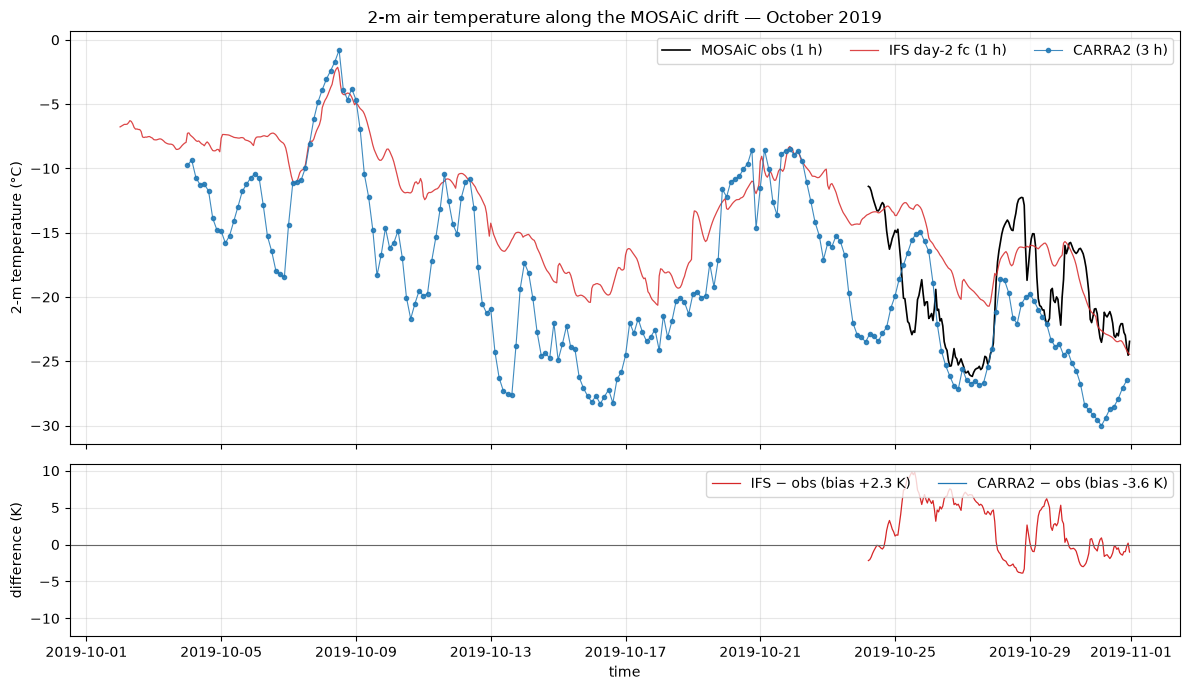

In [7]:
colors = {"MOSAiC obs": "k", "IFS": "tab:red", "CARRA2": "tab:blue"}

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2.4, 1]})

ax = axes[0]
ax.plot(df.index, df["MOSAiC obs"], color=colors["MOSAiC obs"], lw=1.2, label="MOSAiC obs (1 h)")
ax.plot(df.index, df["IFS"], color=colors["IFS"], lw=0.9, alpha=0.85, label="IFS day-2 fc (1 h)")
ax.plot(carra_t2m.index, carra_t2m, "o-", color=colors["CARRA2"], ms=3, lw=0.8,
        alpha=0.85, label="CARRA2 (3 h)")
ax.set_ylabel("2-m temperature (°C)")
ax.legend(ncols=3, loc="upper right")
ax.grid(alpha=0.3)
ax.set_title("2-m air temperature along the MOSAiC drift — October 2019")

ax = axes[1]
for m in ["IFS", "CARRA2"]:
    d = df[m] - df["MOSAiC obs"]
    ax.plot(d.index, d, color=colors[m], lw=0.9,
            label=f"{m} − obs (bias {stat_table.loc['bias (K)', m]:+.1f} K)")
ax.axhline(0, color="0.4", lw=0.8)
ax.set_ylabel("difference (K)")
ax.set_xlabel("time")
ax.legend(ncols=2, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

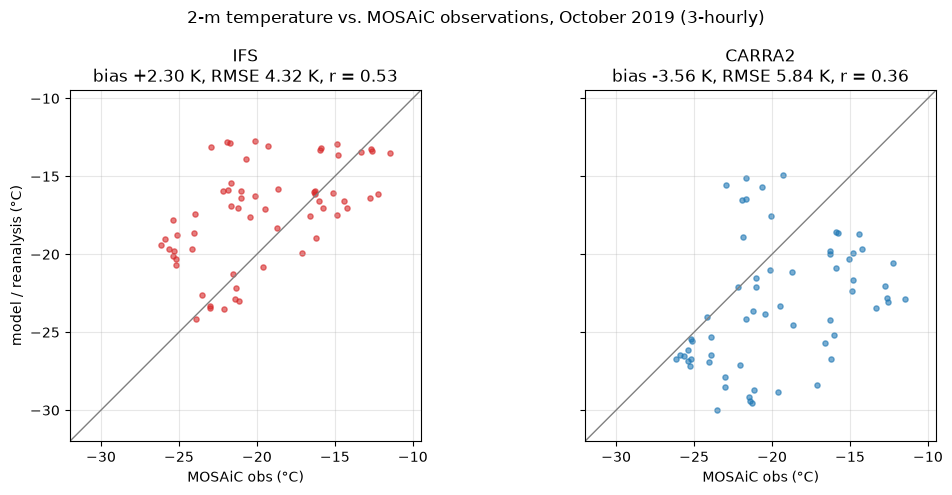

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
lims = [common.min().min() - 2, common.max().max() + 2]

for ax, m in zip(axes, ["IFS", "CARRA2"]):
    ax.plot(lims, lims, color="0.5", lw=1)
    ax.scatter(common["MOSAiC obs"], common[m], s=14, alpha=0.6, color=colors[m])
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_xlabel("MOSAiC obs (°C)")
    ax.set_title(f"{m}\nbias {stat_table.loc['bias (K)', m]:+.2f} K, "
                 f"RMSE {stat_table.loc['RMSE (K)', m]:.2f} K, "
                 f"r = {stat_table.loc['corr', m]:.2f}")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("model / reanalysis (°C)")
fig.suptitle("2-m temperature vs. MOSAiC observations, October 2019 (3-hourly)")
fig.tight_layout()
plt.show()

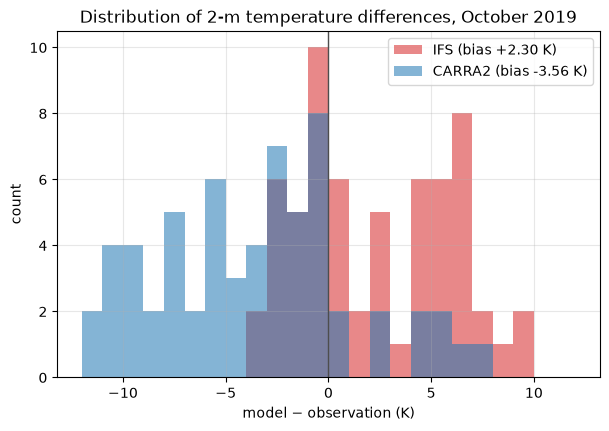

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.arange(-12, 12.5, 1.0)
for m in ["IFS", "CARRA2"]:
    d = (common[m] - common["MOSAiC obs"])
    ax.hist(d, bins=bins, alpha=0.55, color=colors[m],
            label=f"{m} (bias {d.mean():+.2f} K)")
ax.axvline(0, color="0.3", lw=1)
ax.set_xlabel("model − observation (K)")
ax.set_ylabel("count")
ax.set_title("Distribution of 2-m temperature differences, October 2019")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 6. Save the merged comparison

In [10]:
out = DATA_DIR / "t2m_comparison_MOSAiC_IFS_CARRA2_201910.csv"
df.to_csv(out, float_format="%.3f")
print(f"Saved: {out.resolve()}")

Saved: /Users/mauf/Git/polarhack/data/t2m_comparison_MOSAiC_IFS_CARRA2_201910.csv
